# Eksperymenty z metodami preprocessingu obrazów

Celem eksperymentu jest określenie, czy zastosowanie metod poprawy obrazu może zwiększyć skuteczność klasyfikacji znaków drogowych w warunkach obniżonej jasności.

Porównane zostaną:

- obraz bez dodatkowego preprocessingu,
- korekcja gamma,
- wyrównanie histogramu,
- CLAHE.

Eksperyment wykorzystuje ustaloną wcześniej architekturę `ResNet50` oraz strategię `WeightedRandomSampler`.

Wybór metody preprocessingu odbywa się na podstawie wyników uzyskanych na zbiorze walidacyjnym. Zbiór `test_final` pozostaje niezależnym zbiorem końcowej oceny.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.metrics import (
    classification_report,
)

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.transforms import (
    build_eval_transform,
)

from src.data.preprocessing import (
    build_preprocessor,
)

from src.models.resnet50 import (
    create_resnet50,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "preprocessing_analysis"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


for directory in [
    METRICS_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Wczytanie manifestów

In [4]:
train_path = (
    METADATA_DIR
    / "07_train.csv"
)

validation_path = (
    METADATA_DIR
    / "08_validation.csv"
)

test_path = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    train_path
)

validation_df = pd.read_csv(
    validation_path
)

test_df = pd.read_csv(
    test_path
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

Liczba klas: 92


## 2. Wczytanie informacji o poziomie jasności

Wcześniejszy eksperyment wykazał obniżoną skuteczność modelu dla grupy `dark`. Dlatego głównym obszarem dalszej analizy jest wpływ preprocessingu na obrazy o niskiej jasności.

Progi `dark`, `normal` i `bright` są pobierane z wcześniejszego eksperymentu i nie są ponownie wyznaczane na zbiorze testowym.

In [5]:
brightness_path = (
    REPORTS_DIR.parent
    / "lighting_analysis"
    / "brightness_thresholds.json"
)


if brightness_path.exists():

    brightness_info = json.loads(
        brightness_path.read_text(
            encoding="utf-8"
        )
    )

else:

    brightness_path = (
        PROJECT_ROOT
        / "reports"
        / "lighting_analysis"
        / "brightness_thresholds.json"
    )

    brightness_info = json.loads(
        brightness_path.read_text(
            encoding="utf-8"
        )
    )


brightness_p10 = float(
    brightness_info[
        "dark_threshold"
    ]
)

brightness_p90 = float(
    brightness_info[
        "bright_threshold"
    ])


print(
    "Dark threshold:",
    brightness_p10
)

print(
    "Bright threshold:",
    brightness_p90
)

Dark threshold: 59.53968009948732
Bright threshold: 168.24337310791014


## 3. Wczytanie wytrenowanego modelu

Do eksperymentu wykorzystany zostaje najlepszy model ResNet50 uzyskany w poprzednim etapie.

Model nie jest ponownie trenowany w tej fazie przesiewowej. Preprocessing jest stosowany na etapie przygotowania obrazu wejściowego.

In [6]:
checkpoint_path = (
    CHECKPOINT_DIR
    / "resnet50_finetuned_best.pt"
)


if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Brak checkpointu: "
        f"{checkpoint_path}"
    )


resnet50_model = create_resnet50(
    num_classes=len(
        class_codes
    ),
    pretrained=False,
)


state_dict = torch.load(
    checkpoint_path,
    map_location=DEVICE,
)


resnet50_model.load_state_dict(
    state_dict
)

resnet50_model = (
    resnet50_model.to(
        DEVICE
    )
)

resnet50_model.eval()


print(
    "ResNet50 został wczytany."
)

ResNet50 został wczytany.


## 4. Definicja grup jasności dla zbioru walidacyjnego

Obrazy walidacyjne są przypisywane do grup `dark`, `normal` i `bright` przy użyciu progów ustalonych wcześniej na podstawie zbioru treningowego.

In [7]:
def assign_brightness_group(
    value,
):

    if value <= brightness_p10:
        return "dark"

    if value >= brightness_p90:
        return "bright"

    return "normal"

In [8]:
inventory_path = (
    METADATA_DIR
    / "11_full_image_inventory_with_features.csv"
)

if not inventory_path.exists():

    candidates = list(
        METADATA_DIR.glob(
            "*full_image_inventory*.csv"
        )
    )

    if not candidates:
        raise FileNotFoundError(
            "Brak inventory."
        )

    inventory_path = candidates[0]


inventory = pd.read_csv(
    inventory_path
)


validation_lighting = inventory[
    inventory["path"].isin(
        validation_df["path"]
    )
].copy()


validation_lighting[
    "brightness_group"
] = validation_lighting[
    "mean_brightness"
].apply(
    assign_brightness_group
)


print(
    "VALIDATION:",
    len(validation_lighting)
)

display(
    validation_lighting[
        [
            "class_code",
            "mean_brightness",
            "brightness_group",
        ]
    ].head()
)

VALIDATION: 2512


,class_code,mean_brightness,brightness_group
1,A-1,155.213348,normal
14,A-1,116.724442,normal
20,A-1,86.933578,normal
21,A-1,67.869438,normal
37,A-1,47.662846,dark


## 5. Przygotowanie transformacji preprocessingu

Każdy wariant wykorzystuje tę samą procedurę zmiany rozmiaru obrazu i normalizacji. Różnica pomiędzy wariantami występuje wyłącznie w sposobie przetworzenia obrazu przed konwersją do tensora.

In [9]:
from torchvision import transforms


def build_preprocessing_transform(
    method,
    image_size=224,
):

    preprocessor = build_preprocessor(
        method
    )

    return transforms.Compose(
        [
            transforms.Lambda(
                preprocessor
            ),

            transforms.Resize(
                (
                    image_size,
                    image_size
                )
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=(
                    0.485,
                    0.456,
                    0.406
                ),
                std=(
                    0.229,
                    0.224,
                    0.225
                ),
            ),
        ]
    )

## 6. Ocena wariantów preprocessingu na zbiorze walidacyjnym

Na tym etapie porównywane są cztery warianty:

- `original`,
- `gamma`,
- `histogram_equalization`,
- `clahe`.

Wyniki są analizowane globalnie oraz oddzielnie dla grup `dark`, `normal` i `bright`.

In [10]:
methods = [
    "original",
    "gamma",
    "histogram_equalization",
    "clahe",
]


preprocessing_results = []


for method in methods:

    print(
        f"\nOcena: {method}"
    )

    transform = (
        build_preprocessing_transform(
            method,
            image_size=224,
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            validation_path,
            class_to_idx,
            transform=transform,
        )
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            resnet50_model,
            validation_loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    preprocessing_results.append(
        {
            "method": method,
            "scope": "all",
            "samples": len(
                validation_dataset
            ),
            "accuracy": metrics[
                "accuracy"
            ],
            "macro_precision": metrics[
                "macro_precision"
            ],
            "macro_recall": metrics[
                "macro_recall"
            ],
            "macro_f1": metrics[
                "macro_f1"
            ],
            "inference_time_seconds":
                inference_time,
        }
    )


preprocessing_results_df = (
    pd.DataFrame(
        preprocessing_results
    )
)


display(
    preprocessing_results_df
)


Ocena: original

Ocena: gamma

Ocena: histogram_equalization

Ocena: clahe


,method,scope,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,all,2512,0.925159,0.918182,0.926999,0.918303,248.923305
1,gamma,all,2512,0.909236,0.899186,0.903255,0.891599,237.544959
2,histogram_equalization,all,2512,0.793790,0.777183,0.791634,0.758059,239.047087
3,clahe,all,2512,0.810908,0.787882,0.801835,0.755235,230.152545


In [11]:
validation_predictions = (
    validation_df.copy()
)

validation_predictions[
    "true_index"
] = (
    validation_predictions[
        "class_code"
    ]
    .astype(str)
    .map(
        class_to_idx
    )
)

In [12]:
group_results = []


for method in methods:

    transform = (
        build_preprocessing_transform(
            method,
            image_size=224,
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            validation_path,
            class_to_idx,
            transform=transform,
        )
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )


    y_true, y_pred, _ = predict(
        resnet50_model,
        validation_loader,
        DEVICE,
    )


    prediction_df = (
        validation_dataset.data.copy()
    )


    prediction_df[
        "true_index"
    ] = (
        prediction_df[
            "class_code"
        ]
        .astype(str)
        .map(
            class_to_idx
        )
    )


    prediction_df[
        "pred_index"
    ] = y_pred


    lookup = (
        validation_lighting[
            [
                "path",
                "mean_brightness",
                "brightness_group",
            ]
        ]
        .drop_duplicates(
            "path"
        )
    )


    prediction_df = (
        prediction_df
        .merge(
            lookup,
            on="path",
            how="left",
        )
    )


    for group_name in [
        "dark",
        "normal",
        "bright",
    ]:

        group = prediction_df[
            prediction_df[
                "brightness_group"
            ]
            == group_name
        ]


        if len(group) == 0:
            continue


        metrics = evaluate_predictions(
            group[
                "true_index"
            ].to_numpy(),

            group[
                "pred_index"
            ].to_numpy(),
        )


        group_results.append(
            {
                "method": method,
                "brightness_group":
                    group_name,
                "samples":
                    len(group),
                "classes_present":
                    group[
                        "class_code"
                    ].nunique(),
                "accuracy":
                    metrics[
                        "accuracy"
                    ],
                "macro_precision":
                    metrics[
                        "macro_precision"
                    ],
                "macro_recall":
                    metrics[
                        "macro_recall"
                    ],
                "macro_f1":
                    metrics[
                        "macro_f1"
                    ],
            }
        )


group_results_df = pd.DataFrame(
    group_results
)


display(
    group_results_df
)

,method,brightness_group,samples,classes_present,accuracy,macro_precision,macro_recall,macro_f1
0,original,dark,241,53,0.892116,0.877055,0.902209,0.881781
1,original,normal,2032,91,0.927165,0.916530,0.927728,0.917141
2,original,bright,239,50,0.941423,0.879822,0.871316,0.868739
3,gamma,dark,241,53,0.863071,0.749383,0.795918,0.762977
4,gamma,normal,2032,91,0.913878,0.908377,0.916128,0.902387
5,gamma,bright,239,50,0.916318,0.816771,0.846631,0.825537
6,histogram_equalization,dark,241,53,0.697095,0.559568,0.572015,0.538212
7,histogram_equalization,normal,2032,91,0.801673,0.788358,0.804873,0.772937
8,histogram_equalization,bright,239,50,0.824268,0.688790,0.704916,0.682913
9,clahe,dark,241,53,0.755187,0.600667,0.601990,0.581301


## 7. Wybór metody preprocessingu

Metoda preprocessingu jest wybierana na podstawie wartości `macro F1` dla grupy `dark` na zbiorze walidacyjnym.

Wyniki dla pozostałych grup są wykorzystywane jako kryteria pomocnicze.

In [13]:
dark_results = (
    group_results_df[
        group_results_df[
            "brightness_group"
        ]
        == "dark"
    ]
    .sort_values(
        "macro_f1",
        ascending=False,
    )
)


display(
    dark_results
)


best_preprocessing = (
    dark_results.iloc[0][
        "method"
    ]
)


print(
    "Najlepszy preprocessing:",
    best_preprocessing
)

,method,brightness_group,samples,classes_present,accuracy,macro_precision,macro_recall,macro_f1
0,original,dark,241,53,0.892116,0.877055,0.902209,0.881781
3,gamma,dark,241,53,0.863071,0.749383,0.795918,0.762977
9,clahe,dark,241,53,0.755187,0.600667,0.601990,0.581301
6,histogram_equalization,dark,241,53,0.697095,0.559568,0.572015,0.538212


Najlepszy preprocessing: original


## 8. Porównanie metod preprocessingu

Wyniki zostają zestawione dla wszystkich badanych poziomów jasności. Pozwala to określić, czy poprawa jakości klasyfikacji obrazów ciemnych odbywa się kosztem skuteczności dla pozostałych warunków.

In [14]:
comparison = (
    group_results_df
    .pivot(
        index="method",
        columns="brightness_group",
        values="macro_f1",
    )
    .reindex(
        columns=[
            "dark",
            "normal",
            "bright",
        ]
    )
)


display(
    comparison
)

brightness_group,dark,normal,bright
method,,,
clahe,0.581301,0.758260,0.786762
gamma,0.762977,0.902387,0.825537
histogram_equalization,0.538212,0.772937,0.682913
original,0.881781,0.917141,0.868739


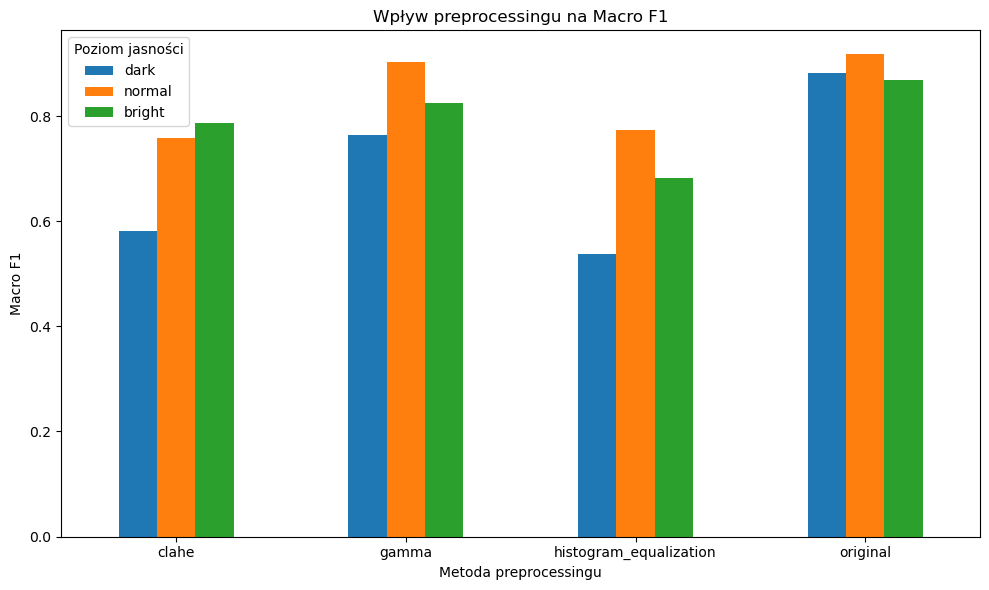

In [15]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)


comparison.plot(
    kind="bar",
    ax=ax,
)


ax.set_title(
    "Wpływ preprocessingu na Macro F1"
)

ax.set_xlabel(
    "Metoda preprocessingu"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend(
    title="Poziom jasności"
)


plt.xticks(
    rotation=0
)

plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_preprocessing_macro_f1_by_brightness.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

In [16]:
preprocessing_results_df.to_csv(
    METRICS_DIR
    / "preprocessing_validation_overall.csv",
    index=False,
    encoding="utf-8-sig",
)


group_results_df.to_csv(
    METRICS_DIR
    / "preprocessing_validation_by_brightness.csv",
    index=False,
    encoding="utf-8-sig",
)

## 9. Końcowa ocena wybranej metody preprocessingu

Po wyborze metody na podstawie wyników walidacyjnych wykonywana jest jedna końcowa ocena na niezależnym zbiorze `test_final`.


In [17]:
selected_method = best_preprocessing

print(
    "Wybrana metoda:",
    selected_method
)

Wybrana metoda: original


In [18]:
selected_transform = (
    build_preprocessing_transform(
        selected_method,
        image_size=224,
    )
)


test_dataset = TrafficSignDataset(
    test_path,
    class_to_idx,
    transform=selected_transform,
)


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)


test_true, test_pred, test_time = (
    predict(
        resnet50_model,
        test_loader,
        DEVICE,
    )
)


final_metrics = evaluate_predictions(
    test_true,
    test_pred,
)


final_test_results = {
    "model": "ResNet50",
    "balancing_strategy":
        "weighted_sampler",
    "preprocessing":
        selected_method,
    "accuracy":
        final_metrics["accuracy"],
    "macro_precision":
        final_metrics["macro_precision"],
    "macro_recall":
        final_metrics["macro_recall"],
    "macro_f1":
        final_metrics["macro_f1"],
    "test_samples":
        len(test_dataset),
    "inference_time_seconds":
        test_time,
}


print(
    json.dumps(
        final_test_results,
        indent=2,
    )
)

{
  "model": "ResNet50",
  "balancing_strategy": "weighted_sampler",
  "preprocessing": "original",
  "accuracy": 0.9001861330851559,
  "macro_precision": 0.8872076792222215,
  "macro_recall": 0.8925747430398414,
  "macro_f1": 0.8829800818611528,
  "test_samples": 4298,
  "inference_time_seconds": 390.2332657999996
}


In [19]:
(
    METRICS_DIR
    / "selected_preprocessing_test_final.json"
).write_text(
    json.dumps(
        final_test_results,
        indent=2,
    ),
    encoding="utf-8",
)

318